In [57]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [58]:
tickers = ["APOLLOHOSP.NS","GRASIM.NS"]

df = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",auto_adjust=False,multi_level_index=False)['Adj Close']

df.columns = ['y','x']   # y dependent, x independent
df = df.ffill().dropna()

# ---------------------------
# 1. Regression (y on x)
# ---------------------------
y = df['y']
x = df['x']

model = sm.OLS(y.iloc[:90], x.iloc[:90]).fit()
beta = model.params.iloc[0]

# ---------------------------
# 2. Spread
# ---------------------------
df['spread'] = y - beta * x

# ---------------------------
# 3. ADF Test
# ---------------------------
adf = adfuller(df['spread'])

t_stat = adf[0]
p_value = adf[1]
crit_10 = adf[4]['10%']

print("ADF:", t_stat)
print("p-value:", p_value)
print("10% critical:", crit_10)

# decision
print("Stationary:", (t_stat < crit_10) and (p_value < 0.05))
print("mean of spread ",df['spread'].mean())

[*********************100%***********************]  2 of 2 completed

ADF: -4.257058722884412
p-value: 0.0005267388766316995
10% critical: -2.568017509711682
Stationary: True
mean of spread  673.9013594023301


Sharpe: -0.3349058642767654
Max Drawdown: -0.5929983278876654


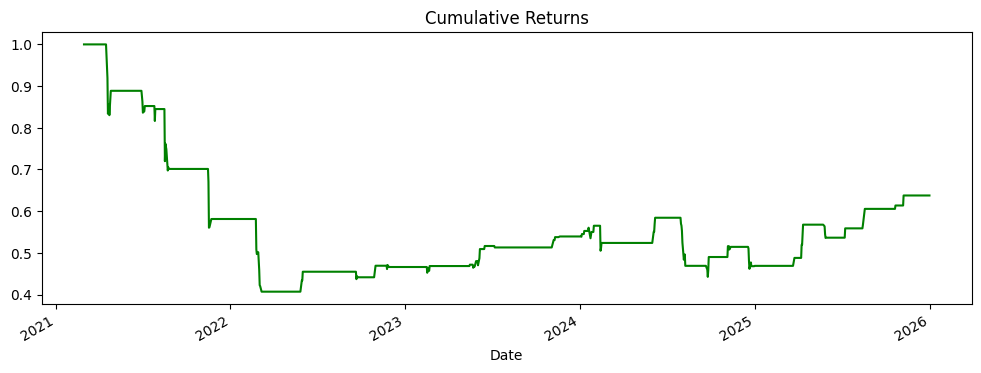

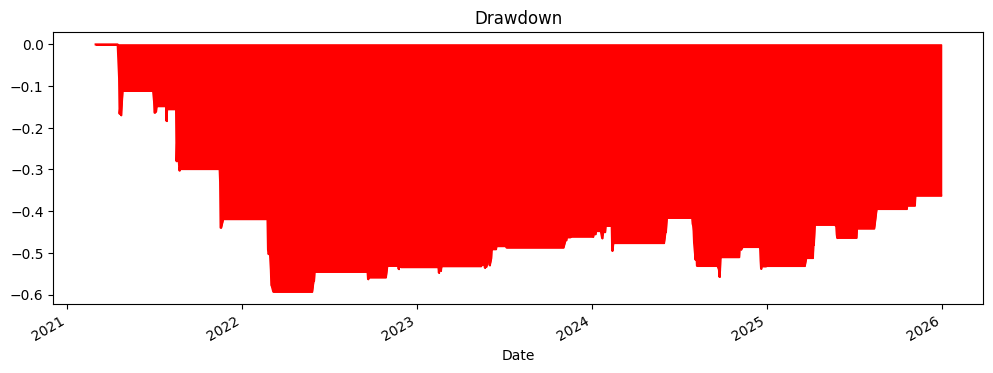

In [61]:
# 5. Rolling stats (NO LEAKAGE)
# ---------------------------
df['r_mean'] = df['spread'].rolling(20).mean().shift(1)
df['r_std'] = df['spread'].rolling(20).std().shift(1)

# ---------------------------
# 6. Z-score
# ---------------------------
df['zscore'] = (df['spread'] - df['r_mean']) / df['r_std']

# ---------------------------
# 7. Drop NaNs (IMPORTANT)
# ---------------------------
df = df.dropna().copy()

# ---------------------------
# 8. Signals (BINARY)
# ---------------------------
entry_z = 2
exit_z = 0

df['long_entry']  = df['zscore'] < -entry_z
df['long_exit']   = df['zscore'] > -exit_z

df['short_entry'] = df['zscore'] > entry_z
df['short_exit']  = df['zscore'] < exit_z

# ---------------------------
# 9. Positions
# ---------------------------
df['position'] = np.nan

df.loc[df['long_entry'], 'position'] = 1
df.loc[df['long_exit'], 'position'] = 0

df.loc[df['short_entry'], 'position'] = -1
df.loc[df['short_exit'], 'position'] = 0

df['position'] = df['position'].ffill().fillna(0)

# ---------------------------
# 10. Returns (CORRECT PnL)
# ---------------------------
df['ret_y'] = df['y'].pct_change()
df['ret_x'] = df['x'].pct_change()

df['strategy_returns'] = df['position'].shift(1) * (
    df['ret_y'] - beta * df['ret_x']
)

df['strategy_returns'] = df['strategy_returns'].fillna(0)

# ---------------------------
# 11. Performance
# ---------------------------
df['cum_returns'] = (1 + df['strategy_returns']).cumprod()

sharpe = df['strategy_returns'].mean() / df['strategy_returns'].std() * np.sqrt(252)
print("Sharpe:", sharpe)

# ---------------------------
# 12. Drawdown
# ---------------------------
df['drawdown'] = df['cum_returns'] / df['cum_returns'].cummax() - 1

print("Max Drawdown:", df['drawdown'].min())

# ---------------------------
# 13. Plots
# ---------------------------
plt.figure(figsize=(12,4))
df['cum_returns'].plot(color='green')
plt.title("Cumulative Returns")
plt.show()

plt.figure(figsize=(12,4))
df['drawdown'].plot(color='red')
plt.fill_between(df.index, df['drawdown'], color='red')
plt.title("Drawdown")
plt.show()

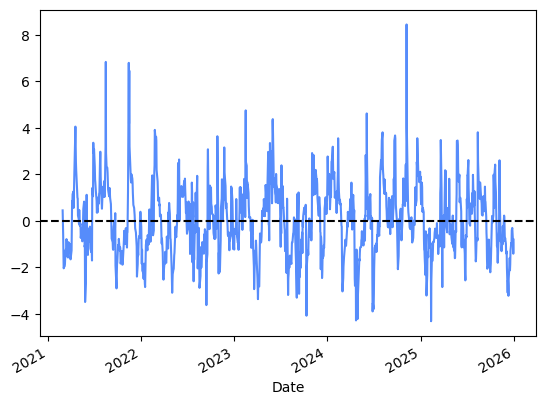

In [65]:
df['zscore'].plot()
plt.axhline(color='black', linestyle='--')

<Axes: >

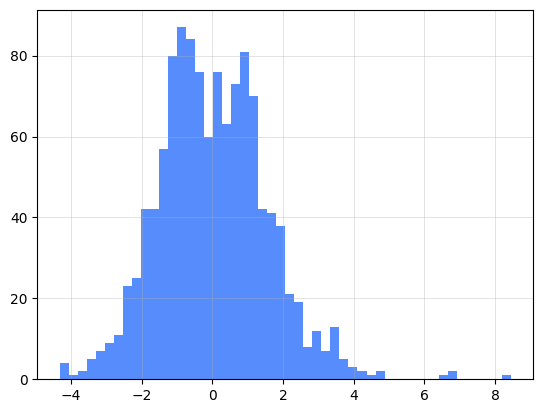

In [66]:
df['zscore'].hist(bins=50)

In [69]:
print('Autocorr',df['spread'].autocorr(lag=1))

Autocorr 0.970673755349178


In [70]:
spread = df['spread'].dropna()

spread_lag = spread.shift(1)
spread_ret = spread - spread_lag

spread_lag = spread_lag.dropna()
spread_ret = spread_ret.dropna()

beta_hl = np.polyfit(spread_lag, spread_ret, 1)[0]

half_life = -np.log(2) / beta_hl
print("Half-life:", half_life)

Half-life: 23.235966891634725
